# EDA (EXPLORATION DES DONNÉES)

### Projet ML/MLops - Scoring du risque de crédit

NB: 1-Mauvais payeur, 0-Bon Payeur (crédit accordé)
Dans la suite nous devons réalisé un EDA complèt, reproductible et orientée machine learnig sur nos 4 souces de donnnées : 
- Applicant.csv: demandes et cible (defaul_paiement)
- credit_history.csv : Les historiques de crédit des clients
- mobile_money_transactions.csv : comportement mobile money des demandeurs
- parteners_metadata.csv: référentiel des partenaires.

## Principes méthodologiques
- Explorer les tables et visualiser les valeurs manquantes
- Graphique des features en fonction de la cible 
- L'historique crédit filtre avec la demande  
- Taux de refus de mauvais payeur par pays et par secteur
- Conclustion    

In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
from matplotlib import pyplot as plt

df_a = pd.read_csv("../data/raw/applicants.csv", low_memory=False, sep=',')
df_c = pd.read_csv("../data/raw/credit_history.csv", low_memory=False, sep=',')
df_m = pd.read_csv("../data/raw/mobile_money_transactions.csv", low_memory=False, sep=',')
df_p = pd.read_csv("../data/raw/partners_metadata.csv", low_memory=False, sep=",")

pd.set_option('display.max_row', 111)
pd.set_option('display.max_columns', 111)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")

### ANALYSE DE FORME 

#### Petit netoyage

In [2]:
def secteur(value:str) -> str:
    if pd.isna(value):
        return np.nan
    value = value.strip().lower()
    if value in {"agri"}:
        return "Agriculture"
    if value in {"artisan"}:
        return "Artisanat"
    if value in {"services"}:
        return "Service"
    if value in {"negoce"}:
        return "Commerce"
    return value.strip().lower().capitalize()
    
df_a['secteur_activite'] = df_a['secteur_activite'].apply(secteur)

def parse_date(val):    
    val = str(val).strip()
    if val.isdigit() and len(val) >= 9:
        return pd.to_datetime(int(val), unit='s')
    for fmt in ("%Y-%m-%d", "%d/%m/%Y", "%d-%m-%Y", "%Y/%m/%d", "%Y/%d/%m" ):
        try:
            return pd.to_datetime(val, format=fmt)
        except ValueError:
            continue
    return pd.NaT


df_c['date_credit']=df_c['date_credit'].apply(parse_date)
df_a['date_demande']=df_a['date_demande'].apply(parse_date)
parsed_dates = df_a["date_demande"].apply(parse_date)

print("Dates non converties :", parsed_dates.isna().sum())
print("Date minimale :", parsed_dates.min())
print("Date maximale :", parsed_dates.max())


def zone(value:str) -> str:
    if pd.isna(value):
        return np.nan
    value = value.strip().lower()
    if value in {"periurbain"}:
        return "Peri-urbain"
    if value in {"urban"}:
        return "Urbain"
    return value.capitalize()

df_a['zone'] = df_a['zone'].apply(zone) 

def pays(value:str) -> str:
    if pd.isna(value):
        return np.nan
    value = value.strip().lower()
    if value in {"cameroun"}:
        return "CMR"
    if value in {"congo"}:
        return "COG"
    if value in {"guinee eq."}:
        return "GNQ"
    if value in {"tchad"}:
        return "TCD"
    if value in {"gabon"}:
        return "GAB"
    return value.upper()  

df_a['pays'] = df_a['pays'].apply(pays)


def statut(value:str) -> str:
    if pd.isna(value):
        return np.nan
    value = value.strip().lower()
    if value in {"encours", "actif", "en cours"}:
        return "En_cours"
    if value in {"cloture"}:
        return "Rembourse"
    if value in {'impaye'}:
        return "Defaut"
    
    return value.capitalize()
   
df_c['statut_final'] = df_c['statut_final'].apply(statut)   

Dates non converties : 51000
Date minimale : NaT
Date maximale : NaT


In [9]:
df_a['secteur_activite'].unique()

<ArrowStringArray>
['Agriculture', 'Commerce', 'Service', 'Artisanat', 'Elevage', 'Pastoral']
Length: 6, dtype: str

#### Idée globale sur les données du DATASET

In [6]:
df = {
    "Applicant" : df_a,
    "credit" : df_c,
    "mobile_money": df_m,
    "partners":df_p    
}
for key,value in df.items():    
    print(f'='*30+f'{key}'+'='*30)
    print(f"Shape {key} of dataset : {value.shape}")
    print(f"information of dataset :{value.info()} \n" )

==============================Applicant==============================
Shape Applicant of dataset : (51000, 13)
<class 'pandas.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   applicant_id        51000 non-null  str    
 1   age                 51000 non-null  int64  
 2   pays                51000 non-null  str    
 3   secteur_activite    51000 non-null  str    
 4   revenu_mensuel_xaf  49468 non-null  float64
 5   anciennete_emploi   50491 non-null  float64
 6   ratio_endettement   50492 non-null  float64
 7   historique_credit   41801 non-null  float64
 8   nb_credits_actifs   51000 non-null  int64  
 9   mobile_money_score  36725 non-null  float64
 10  zone                51000 non-null  str    
 11  date_demande        51000 non-null  str    
 12  defaut_paiement     51000 non-null  int64  
dtypes: float64(5), int64(3), str(5)
memory usage: 7.1 M

#### Examiner les données (les decrires) et les valeurs manquantes  

In [7]:
df = {
    "Applicant" : df_a,
    "credit" : df_c,
    "mobile_money": df_m,
    "partners":df_p    
}
for key,value in df.items():    
    print(f'='*30+f'{key}'+'='*30)
    print(f" {value.describe().T} \n")

==============================Applicant==============================
                        count       mean        std         min       25%  \
age                51,000.00      46.34      16.84       14.00     32.00   
revenu_mensuel_xaf 49,468.00 254,475.27 264,687.98 -199,900.00 99,800.00   
anciennete_emploi  50,491.00      55.14      37.16        0.00     22.00   
ratio_endettement  50,492.00       0.37       0.42        0.00      0.17   
historique_credit  41,801.00     574.95     158.83      300.00    437.00   
nb_credits_actifs  51,000.00       1.40       1.19        0.00      1.00   
mobile_money_score 36,725.00      60.07      20.04        2.40     45.70   
defaut_paiement    51,000.00       0.12       0.33        0.00      0.00   

                          50%        75%          max  
age                     46.00      61.00        75.00  
revenu_mensuel_xaf 177,800.00 315,900.00 5,000,000.00  
anciennete_emploi       55.00      87.00       120.00  
ratio_endettement   

#### Pourcentage de valeur manquante

In [165]:
df = {
    "Applicant" : df_a,
    "credit" : df_c,
    "mobile_money": df_m,
    "partners":df_p    
}
for key,value in df.items():    
    missing_rate = value.isna().sum()/value.shape[0]*100
    print(f'='*30+f'{key}'+'='*30)
    print(f'shape : {value.shape}')
    print(f"{missing_rate}")


==============================Applicant==============================
shape : (51000, 13)
applicant_id          0.00
age                   0.00
pays                  0.00
secteur_activite      0.00
revenu_mensuel_xaf    3.00
anciennete_emploi     1.00
ratio_endettement     1.00
historique_credit    18.04
nb_credits_actifs     0.00
mobile_money_score   27.99
zone                  0.00
date_demande          0.00
defaut_paiement       0.00
dtype: float64
==============================credit==============================
shape : (101913, 9)
applicant_id       0.00
credit_id          0.00
montant_xaf        0.00
duree_mois         0.00
nb_retards         0.00
jours_retard_max   1.50
statut_final       0.00
partenaire_id      0.00
date_credit        0.00
dtype: float64
==============================mobile_money==============================
shape : (36000, 7)
applicant_id             0.00
nb_transactions_mois     0.00
volume_entrant_xaf       1.00
volume_sortant_xaf       1.00
regularite_sco

Affichage en pourcentage des valeurs manquantes dans une dataset

#### Valeurs uniques dans les datasets

In [166]:
df = {
    "Applicant" : df_a,
    "credit" : df_c,
    "mobile_money": df_m,
    "partners":df_p    
}
for key,value in df.items():    
    print(f"{value.columns}")
    print(f'='*30+f'{key}'+'='*30)
    print(f'shape : {value.shape}')
    print(f" {value.nunique()} \n")


Index(['applicant_id', 'age', 'pays', 'secteur_activite', 'revenu_mensuel_xaf',
       'anciennete_emploi', 'ratio_endettement', 'historique_credit',
       'nb_credits_actifs', 'mobile_money_score', 'zone', 'date_demande',
       'defaut_paiement'],
      dtype='str')
==============================Applicant==============================
shape : (51000, 13)
 applicant_id          50000
age                      62
pays                     19
secteur_activite         15
revenu_mensuel_xaf     8708
anciennete_emploi       121
ratio_endettement      2241
historique_credit       551
nb_credits_actifs         9
mobile_money_score      956
zone                     11
date_demande           5831
defaut_paiement           2
dtype: int64 

Index(['applicant_id', 'credit_id', 'montant_xaf', 'duree_mois', 'nb_retards',
       'jours_retard_max', 'statut_final', 'partenaire_id', 'date_credit'],
      dtype='str')
==============================credit==============================
shape : (101913, 9)

#### Valeur dupliquer des datasets

In [167]:
df = {
    "Applicant" : df_a,
    "credit" : df_c,
    "mobile_money": df_m,
    "partners":df_p    
}
for key,value in df.items():    
    print(f"{key} : {value.duplicated().sum()} duplicated, le pourcentage : {value.duplicated().sum()/value.shape[0] * 100 :.2f} %")

Applicant : 1000 duplicated, le pourcentage : 1.96 %
credit : 0 duplicated, le pourcentage : 0.00 %
mobile_money : 0 duplicated, le pourcentage : 0.00 %
partners : 0 duplicated, le pourcentage : 0.00 %


Nous pouvons voir le poucentage de duplication dans les datasets

#### Distribution de la target/cible

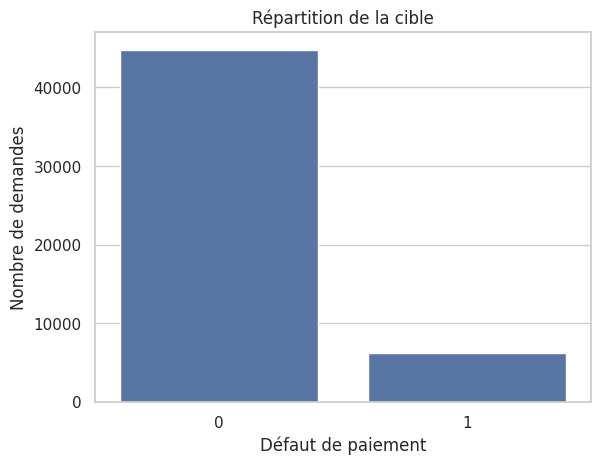

In [168]:
sns.countplot(data=df_a, x="defaut_paiement")
plt.title("Répartition de la cible")
plt.xlabel("Défaut de paiement")
plt.ylabel("Nombre de demandes")
plt.show()

Nous remarquons que nous avons une classe déséquilibré, donc le accurancy score ne serais pas une métrique fiable pour ce dataset, il vaudrais mieux utilisé AUC-ROC ou le PR-AUC, ainsi qu'un classification_report et un learning_curve (pour voir si avec plus de données le modèle seras mieux entrainer) pour nos métrique.   

### ANALYSE DE FORME

#### Detection des anomalies dans applications.csv

<Axes: >

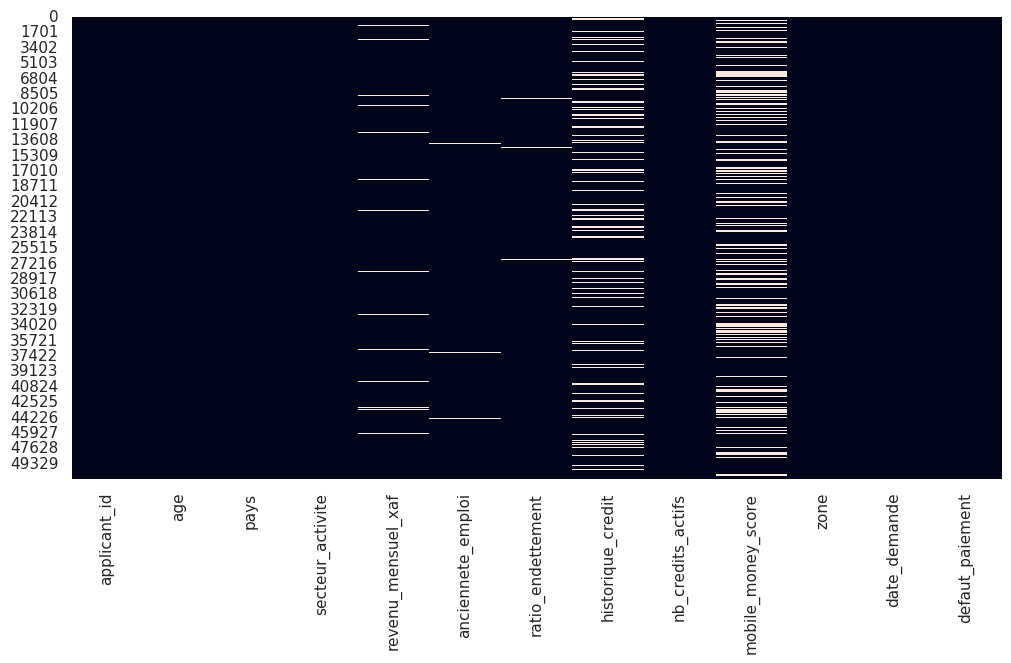

In [169]:
plt.figure(figsize=(12,6))
sns.heatmap(df_a.isna(), cbar=False)

Les lignes projettes (entre plusieurs variable) generallement les corrélation forte enre deux variable. Nous montrons dans ce graphique les données qui sont les manquants dans notre dataset. 

<Axes: >

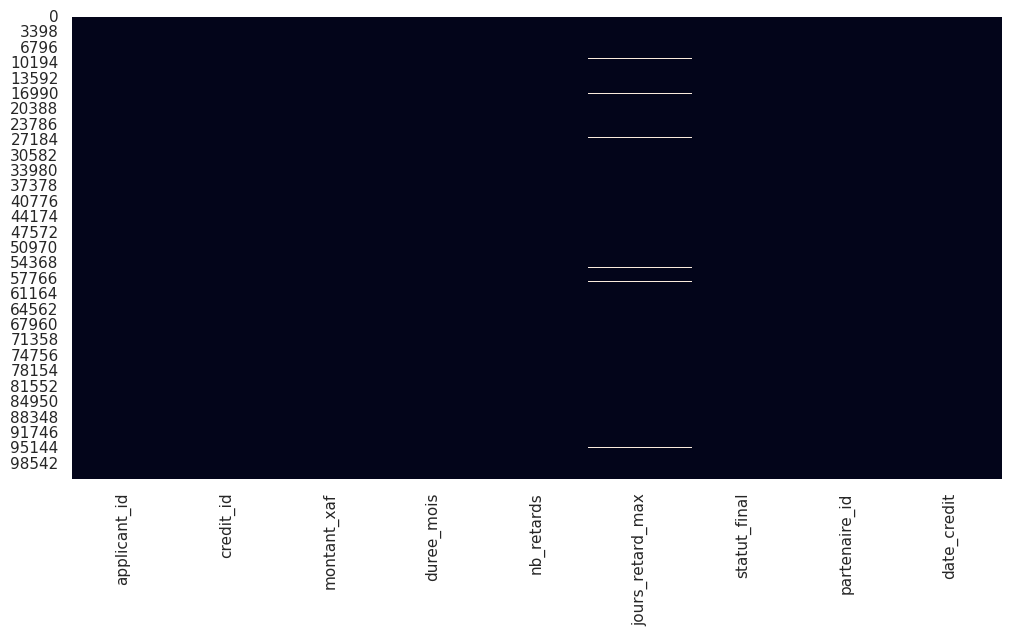

In [170]:
plt.figure(figsize=(12,6))
sns.heatmap(df_c.isna(), cbar=False)

#### CIBLE/TARGET

In [9]:
# Proportion de la CIBLE dans le datasets 
df_a['defaut_paiement'].value_counts(normalize=True,dropna=False)

defaut_paiement
0   0.88
1   0.12
Name: proportion, dtype: float64

#### Pourcentage de solvabilité par secteur

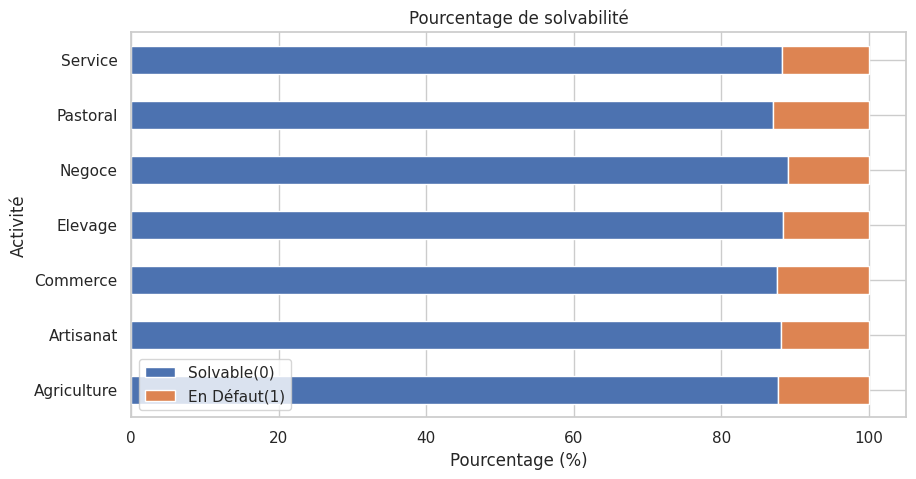

In [13]:
# Pourcentage de solvabilité par Secteur.

df_secteur = pd.crosstab(df_a['secteur_activite'], df_a['defaut_paiement'], normalize='index') * 100

df_secteur.plot(kind='barh', stacked=True, figsize=(10,5))
plt.title("Pourcentage de solvabilité")
plt.xlabel('Pourcentage (%)')
plt.ylabel("Activité")
plt.legend(['Solvable(0)', 'En Défaut(1)'],loc='lower left')
plt.show()

D'après le graphique nous pouvons voir que assez de personne, n'ont pas été solvable (crédit accordé mais n'ont pas payé)  

#### Primo-demandeur

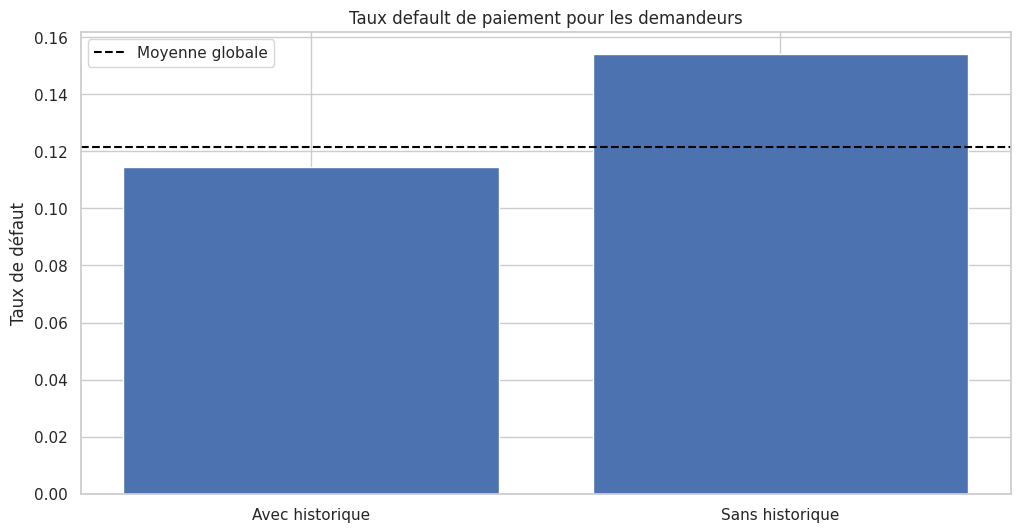

In [14]:
plt.figure(figsize=(12,6))

df_a['primo_demandeur'] = df_a['historique_credit'].isna()
df_a.head(5)

prim_demandeur = df_a.groupby('primo_demandeur')['defaut_paiement'].mean()
plt.bar(
    ['Avec historique', 'Sans historique'], 
    prim_demandeur.values,    
) 
plt.title('Taux default de paiement pour les demandeurs')
plt.ylabel("Taux de défaut")
plt.axhline(df_a['defaut_paiement'].mean(), color='black', linestyle='--', label='Moyenne globale')
plt.legend()
plt.show()

D'après le graphique on peut voir que les personnes qui ont plus de credit ce sont des personnes qui n'ont pas d'historique

#### Plage de revenu mensuelle des demandeurs

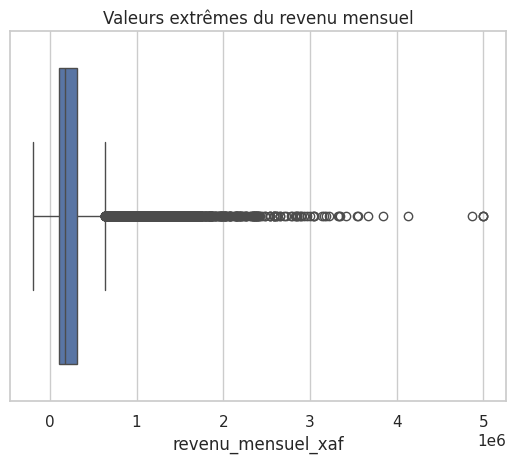

In [15]:
sns.boxplot(
    data=df_a,
    x="revenu_mensuel_xaf"
)
plt.title("Valeurs extrêmes du revenu mensuel")
plt.show()

#### Ration endettement des demandeurs de credit.

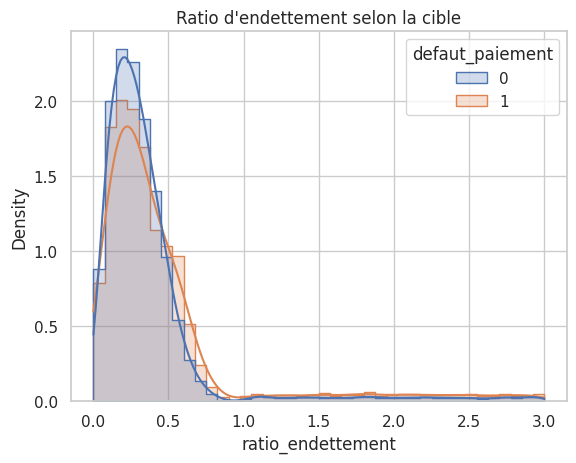

In [175]:

sns.histplot(
    data=df_a,
    x="ratio_endettement",
    hue="defaut_paiement",
    stat="density",
    common_norm=False,
    bins=40,
    element="step",
    kde=True
)
plt.title("Ratio d'endettement selon la cible")
plt.show()

On observe une relation plutôt normal a peu près entre le ration d'endettement et la solvabilité pour les demandes de crédit.

#### Histogrammes des varaibles continues

Variation des features (variable) en fonction de la cible (defaut_paiement).

/tmp/ipykernel_52954/662942042.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


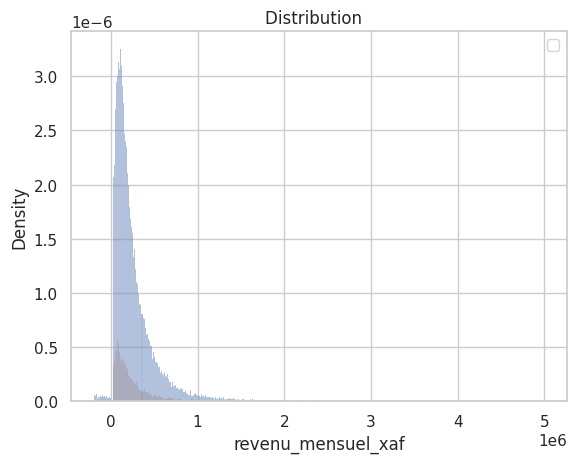

/tmp/ipykernel_52954/662942042.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


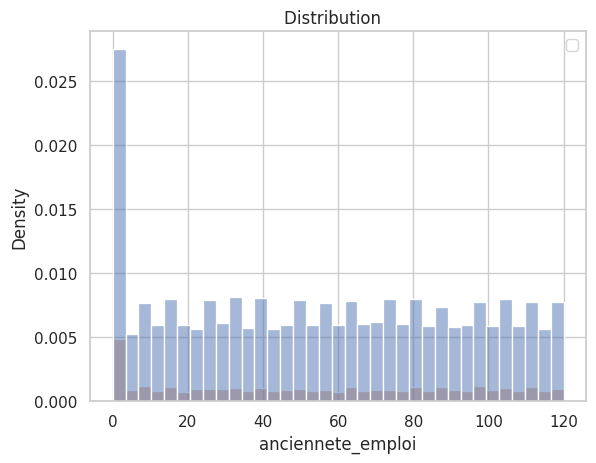

/tmp/ipykernel_52954/662942042.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


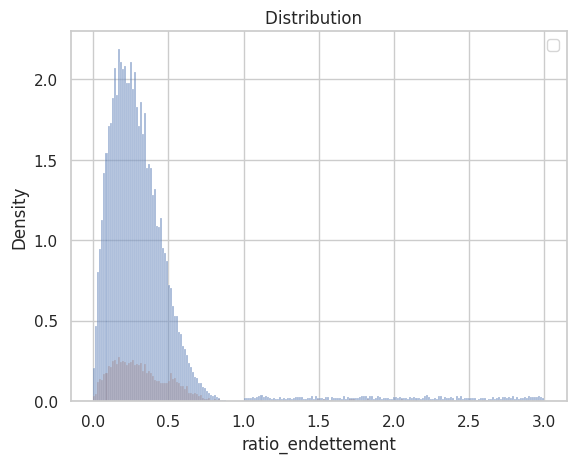

/tmp/ipykernel_52954/662942042.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


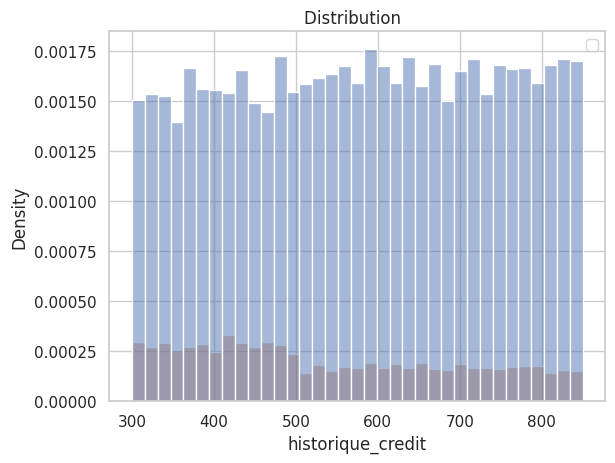

/tmp/ipykernel_52954/662942042.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


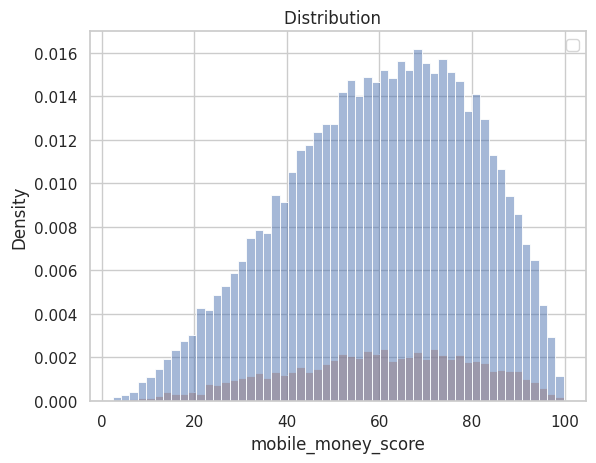

In [ ]:
for col in df_a.select_dtypes('float'):
    plt.figure()
    sns.histplot(
            data=df_a,
            x=df_a[col],
            hue="defaut_paiement",
            stat="density"
        )
    plt.legend()
    plt.title(f"Distribution default_paiement ")
    plt.show()

#### Demandeur par secteur

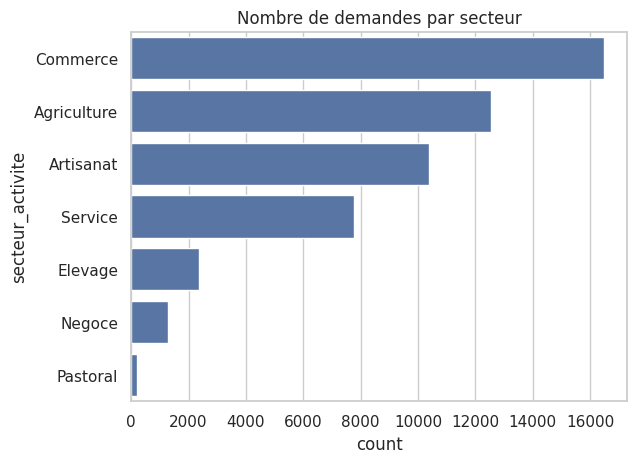

In [21]:
sns.countplot(
    data=df_a,
    y="secteur_activite",
    order=df_a["secteur_activite"].value_counts().index
)
plt.title("Nombre de demandes par secteur")
plt.show()

#### Default par pays 

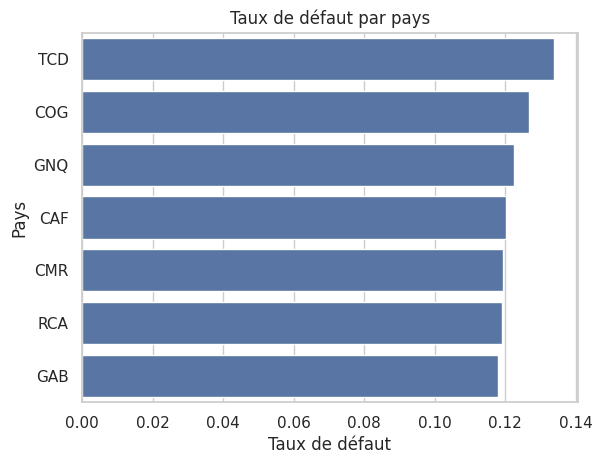

In [22]:
default_by_country = (
    df_a
    .groupby("pays", dropna=False)["defaut_paiement"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
    .reset_index()
)

sns.barplot(
    data=default_by_country,
    x="mean",
    y="pays"
)
plt.title("Taux de défaut par pays")
plt.xlabel("Taux de défaut")
plt.ylabel("Pays")
plt.show()

#### Corrélation entre les variables 

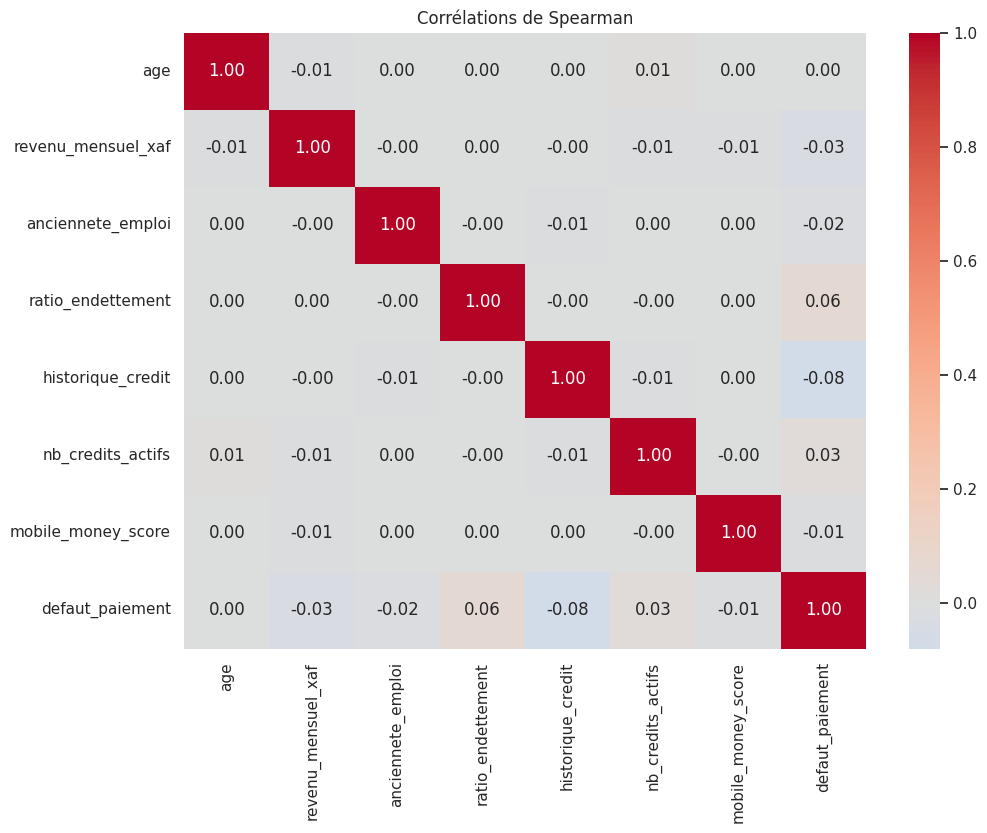

In [181]:
numeric_columns = df_a.select_dtypes(
    include="number"
).columns

correlation_matrix = df_a[
    numeric_columns
].corr(method="spearman")

plt.figure(figsize=(11, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Corrélations de Spearman")
plt.show()

#### Evaluer le revenu_mensuel au ration_endettement en fonction de la cible

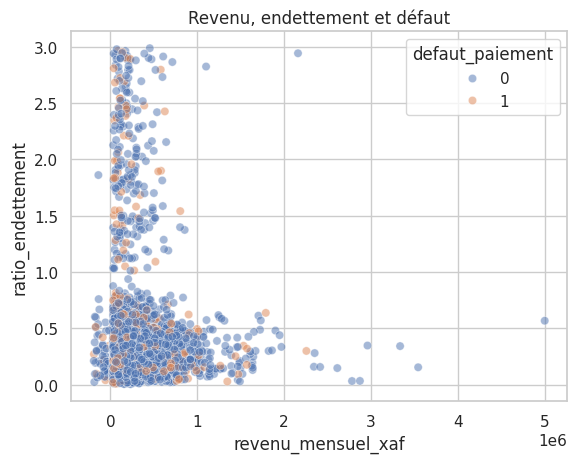

In [182]:
sns.scatterplot(
    data=df_a.sample(
        min(5000, len(df_a)),
        random_state=42
    ),
    x="revenu_mensuel_xaf",
    y="ratio_endettement",
    hue="defaut_paiement",
    alpha=0.5
)
plt.title("Revenu, endettement et défaut")
plt.show()

#### Voir si il y a une influence entre des anciennetes d'emploi et default_paiement

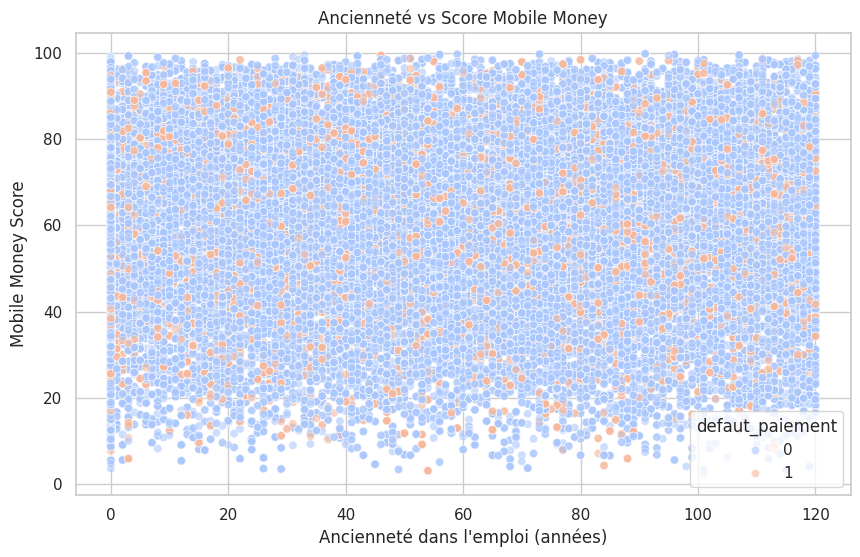

In [38]:
df_complet = pd.merge(
    df_a, df_c, on='applicant_id', how='inner'
)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_complet, x='anciennete_emploi', y='mobile_money_score', hue='defaut_paiement', alpha=0.6, palette='coolwarm')
plt.title('Ancienneté vs Score Mobile Money')
plt.xlabel('Ancienneté dans l\'emploi (années)')
plt.ylabel('Mobile Money Score')
plt.show()

In [39]:
df_complet_part = pd.merge(
    df_complet, df_p, on='partenaire_id' , how='inner'
)

display(df_complet_part)


,applicant_id,age,pays_x,secteur_activite,revenu_mensuel_xaf,anciennete_emploi,ratio_endettement,historique_credit,nb_credits_actifs,mobile_money_score,zone,date_demande,defaut_paiement,primo_demandeur,credit_id,montant_xaf,duree_mois,nb_retards,jours_retard_max,statut_final,partenaire_id,date_credit,nom,type,pays_y,seuil_score,volume_mensuel
0,FIN-1006-1583,61,CMR,Commerce,"195,000.00",0.00,0.39,673.00,2,47.50,Rural,2024-09-25,0,False,CRED-41782,"50,000.00",6,2,88.00,Restructure,PTN-0156,2020-04-16,AllianceFin TCD 33,cooperative,GAB,485,182
1,FIN-1006-1583,61,CMR,Commerce,"195,000.00",0.00,0.39,673.00,2,47.50,Rural,2024-09-25,0,False,CRED-83663,"570,000.00",18,4,21.00,Restructure,PTN-0121,2022-09-29,ZenithMicro COG 22,microfinance,GNQ,681,87
2,FIN-1006-1583,61,CMR,Commerce,"195,000.00",0.00,0.39,673.00,2,47.50,Rural,2024-09-25,0,False,CRED-39283,"190,000.00",18,5,99.00,Restructure,PTN-0074,2022-06-10,CapSud TCD 7,mobile_money,CMR,497,485
3,FIN-1013-1538,48,CMR,Agriculture,"94,600.00",3.00,0.04,NaN,0,75.70,Peri-urbain,2025-04-07,0,True,CRED-30265,"270,000.00",24,0,0.00,Rembourse,PTN-0122,2020-07-08,FondasFin GNQ 33,mobile_money,GAB,639,572
4,FIN-1013-1538,48,CMR,Agriculture,"94,600.00",3.00,0.04,NaN,0,75.70,Peri-urbain,2025-04-07,0,True,CRED-57083,"165,000.00",12,0,0.00,Cloture,PTN-0086,2021-09-22,KamoFin GNQ 35,cooperative,CAF,681,1123
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105896,FIN-1000-1860,60,COG,Commerce,"616,500.00",72.00,0.33,NaN,0,75.20,Peri-urbain,2024-10-30,0,True,CRED-16824,"795,000.00",18,0,0.00,Rembourse,PTN-0002,2021-06-20,CreditPop GNQ 38,banque,CMR,507,34
105897,FIN-1000-1860,60,COG,Commerce,"616,500.00",72.00,0.33,NaN,0,75.20,Peri-urbain,2024-10-30,0,True,CRED-22446,"655,000.00",6,0,0.00,En_cours,PTN-0049,2024-05-30,BarakaCredit GNQ 34,mobile_money,CMR,646,544
105898,FIN-1015-1795,45,COG,Commerce,"509,100.00",0.00,0.38,574.00,1,NaN,Rural,2022-10-22,0,False,CRED-78622,"340,000.00",12,0,0.00,Cloture,PTN-0047,2024-08-14,ZenithMicro GNQ 22,microfinance,COG,702,1140
105899,FIN-1015-1795,45,COG,Commerce,"509,100.00",0.00,0.38,574.00,1,NaN,Rural,2022-10-22,0,False,CRED-23308,"845,000.00",18,0,0.00,Rembourse,PTN-0061,2024-05-18,MicroFin GAB 46,mobile_money,CMR,661,528


#### Temporalité de paiement

Nombre de demande par mois, ainsi que le taux de defautls

In [24]:
dated = df_a.dropna(subset=['date_demande']).copy()
monthly = (
    dated.set_index('date_demande')['defaut_paiement']
    .resample("ME")
    .agg(demandes='count', taux_default='mean')
    .reset_index()
)

display(monthly)

,date_demande,demandes,taux_default
0,2022-01-31,1109,0.11
1,2022-02-28,961,0.13
2,2022-03-31,1037,0.14
3,2022-04-30,1045,0.12
4,2022-05-31,1058,0.12
5,2022-06-30,1021,0.11
6,2022-07-31,1098,0.13
7,2022-08-31,1049,0.13
8,2022-09-30,1075,0.12
9,2022-10-31,1073,0.14


In [28]:
df_c.head(5)

,applicant_id,credit_id,montant_xaf,duree_mois,nb_retards,jours_retard_max,statut_final,partenaire_id,date_credit
0,FIN-1006-1583,CRED-41782,"50,000.00",6,2,88.00,Restructure,PTN-0156,2020-04-16
1,FIN-1006-1583,CRED-83663,"570,000.00",18,4,21.00,Restructure,PTN-0121,2022-09-29
2,FIN-1006-1583,CRED-39283,"190,000.00",18,5,99.00,Restructure,PTN-0074,2022-06-10
3,FIN-1013-1538,CRED-30265,"270,000.00",24,0,0.00,Rembourse,PTN-0122,2020-07-08
4,FIN-1013-1538,CRED-57083,"165,000.00",12,0,0.00,Cloture,PTN-0086,2021-09-22


#### Voir les status des crédits

In [31]:
status_table = df_c['statut_final'].value_counts().rename_axis("statut").reset_index(name='effectif')
display(status_table)


,statut,effectif
0,Rembourse,62299
1,En_cours,22183
2,Defaut,7688
3,Cloture,4897
4,Restructure,4366
5,Impaye,480


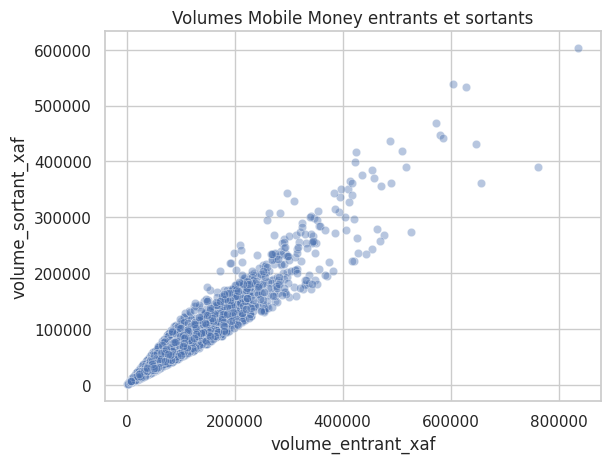

In [187]:
sns.scatterplot(
    data=df_m.sample(
        min(5000, len(df_m)),
        random_state=42
    ),
    x="volume_entrant_xaf",
    y="volume_sortant_xaf",
    alpha=0.4
)
plt.title("Volumes Mobile Money entrants et sortants")
plt.show()

In [40]:
hist_agg = df_c.groupby('applicant_id').agg(
    nb_credits_passes=('credit_id', 'count'),
    total_retards_passes=('nb_retards', 'sum'),
    max_jours_retard_absolu=('jours_retard_max', 'max'),
    montant_total_emprunte=('montant_xaf', 'sum')
).reset_index()

# 2. Fusion avec le dataset principal (ajustez le nom de la clé du dataset principal si nécessaire)
df_complet = pd.merge(df_a, hist_agg, left_on='applicant_id', right_on='applicant_id', how='left')

# 3. Remplacer les valeurs manquantes par 0 pour les nouveaux clients (sans historique)
colonnes_hist = ['nb_credits_passes', 'total_retards_passes', 'max_jours_retard_absolu', 'montant_total_emprunte']
df_complet[colonnes_hist] = df_complet[colonnes_hist].fillna(0)

#### DEfaut selon le statut

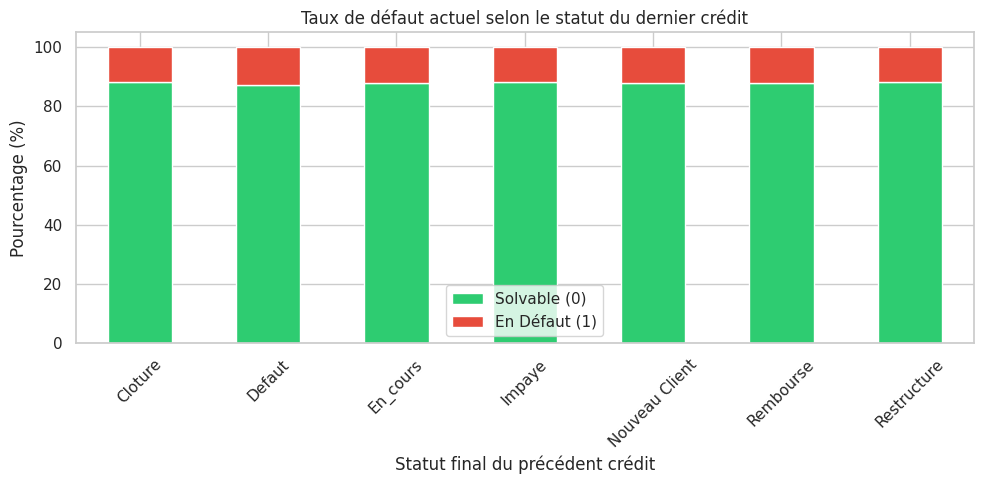

In [41]:
# On récupère le dernier statut de crédit connu pour chaque client avant agrégation
dernier_statut = df_c.sort_values('date_credit').groupby('applicant_id').last()['statut_final'].reset_index()
df_complet = pd.merge(df_complet, dernier_statut, on='applicant_id', how='left').fillna({'statut_final': 'Nouveau Client'})

# Graphique en barres empilées à 100%
df_cross = pd.crosstab(df_complet['statut_final'], df_complet['defaut_paiement'], normalize='index') * 100
df_cross.plot(kind='bar', stacked=True, figsize=(10, 5), color=['#2ecc71', '#e74c3c'])

plt.title('Taux de défaut actuel selon le statut du dernier crédit')
plt.ylabel('Pourcentage (%)')
plt.xlabel('Statut final du précédent crédit')
plt.xticks(rotation=45)
plt.legend(['Solvable (0)', 'En Défaut (1)'])
plt.tight_layout()
plt.show()


Nous pouvons remarquer que les defaults de crédit sont presque pareil. 

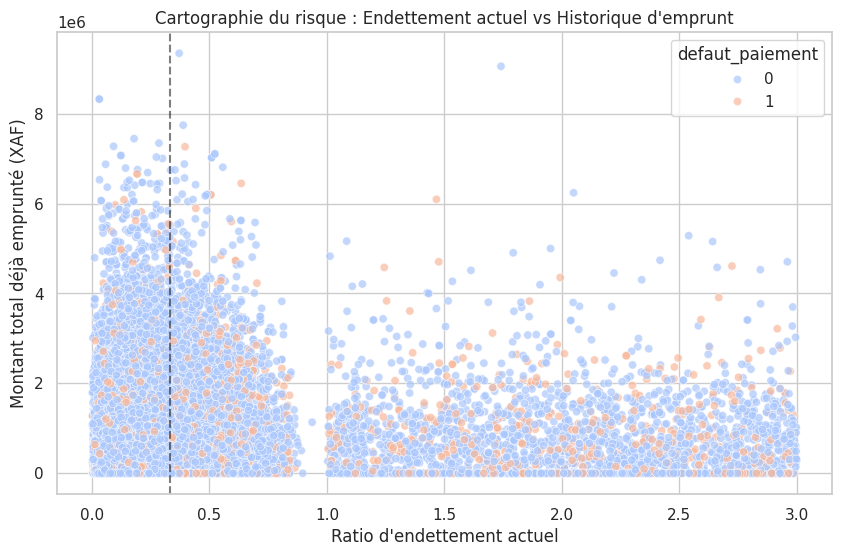

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_complet, 
    x='ratio_endettement', 
    y='montant_total_emprunte', 
    hue='defaut_paiement', 
    alpha=0.7, 
    palette='coolwarm'
)
plt.title('Cartographie du risque : Endettement actuel vs Historique d\'emprunt')
plt.xlabel('Ratio d\'endettement actuel')
plt.ylabel('Montant total déjà emprunté (XAF)')
plt.axvline(x=0.33, color='black', linestyle='--', alpha=0.5) 
plt.show()


#### Application CV
- Données doubler (doublons) sur les ID qui sont ressoumissions 1000 lignes (1.97%)
- Données manquantes revenu_mensuel_xaf (3%), historique_credit(18%), mony(27%)
- Normalisation des zone, date_demande, secteur_dactivite, pays
- construitre une feature pour n'accorder que les prêts au majeur âge >=18 
- D'apres la heatmap, les valuers a surveiller son historique_credit, ratio_endettement, le revenu_mensuel_xaf, mobile_money_score
- Ceux qui demande le crédit son plus des commercans, agriculteur, artisanat
- Plus de demande de credit au Tchad avec un taux défaut plus élevé
- Beaucoup de demandeur de credits on un historique crédit


#### Credit_history
- Données manquantes sur le jour retard dans credit (1,5%)
- Normalisation date_credit, statut_final

#### Mobile_money
- Dans le mobile volume entrant et sortante (1%), redularite_score(2%)
- Normalisation des operateurs

Faire une jointure entre les applicant cv et les credits history

# Conclusion
## Point de conclusion
 - Classe désiquilibrer  
 - Nous decidons de ne pas imputer les valuers manquantes
 - Modèle de classification du simple au plus complexe (Logistics Regression, RandomForest, XGBoost) 
 - Ajoutez les hyperParamtre au modèle
 - Cross validation pour l'entrainement Stratified K-Fold-CrossValidation
 - Comparaison des modèles de prediction 
 - Métrique PR-AUC, Matrice de Confusion, AUC-ROC, Rappel , Precision , F1_score , et l'utilisation de class_weight='balanced' pour penaliser plus lourdement les erreurs pour les mauvais payeurs
 - L'utilisation de SMOTE pour créer les faux exemple de mauvais payeurs et equilibrer le jeux de données   
 